# Validation PSNR Training Curve Comparison

Compares validation PSNR curves for `netG-only`, `netG+netH`, and `PPDM`. The plot marks the best checkpoint for each run and marks an early-stopped point only when an explicit early-stop signal is found in the logs.

In [1]:
from pathlib import Path

OUTPUT_DIR = Path("/mnt/newdisk/Documents/linzhanyang/DehazeDDPM/plot/ch5_ablation")

RUNS = [
    {
        "label": "netG-only",
        "path": Path("/mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/Dehaze_ColdFog_finetune_only_diffusion_260417_152053"),
        "color": "#4C78A8",
        "marker": "o",
    },
    {
        "label": "netG+netH",
        "path": Path("/mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/Dehaze_ColdFog_finetune_netH_260406_223953"),
        "color": "#F58518",
        "marker": "s",
    },
    {
        "label": "PPDM",
        "path": Path("/mnt/newdisk/Documents/linzhanyang/DehazeDDPM/experiments/Dehaze_ColdFog_finetune_netH_physical_v1_260508_123402"),
        "color": "#54A24B",
        "marker": "^",
    },
]


In [2]:
%matplotlib inline

import re

import matplotlib.pyplot as plt

TEXTWIDTH_IN = 5.768

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": False,
})

LINE_VAL = re.compile(
    r"<epoch:\s*(\d+),\s*iter:\s*([\d,\s]+)>\s+psnr:\s*([\deE.+-]+)"
)
LINE_ITER = re.compile(r"iter:\s*([\d,\s]+)")
EARLY_STOP = re.compile(r"early[-\s]?stopp?ed|early[-\s]?stop|stopping early", re.IGNORECASE)


def parse_iter(text):
    return int(re.sub(r"[\s,]", "", text))


def parse_val_log(exp_dir):
    val_path = exp_dir / "logs" / "val.log"
    train_path = exp_dir / "logs" / "train.log"
    source = val_path if val_path.exists() else train_path
    if not source.exists():
        raise FileNotFoundError(f"Missing log file under {exp_dir}")

    points = []
    for line in source.read_text(encoding="utf-8", errors="replace").splitlines():
        match = LINE_VAL.search(line)
        if match:
            epoch = int(match.group(1))
            iteration = parse_iter(match.group(2))
            psnr = float(match.group(3))
            points.append({"epoch": epoch, "iteration": iteration, "psnr": psnr})

    if not points:
        raise ValueError(f"No validation PSNR entries found in {source}")
    return points, source


def detect_early_stop(exp_dir, points):
    for name in ("train.log", "val.log"):
        path = exp_dir / "logs" / name
        if not path.exists():
            continue
        for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
            if not EARLY_STOP.search(line):
                continue
            match = LINE_ITER.search(line)
            if match:
                stop_iter = parse_iter(match.group(1))
                nearest = min(points, key=lambda p: abs(p["iteration"] - stop_iter))
                return {**nearest, "line": line.strip(), "source": path}
            return {**points[-1], "line": line.strip(), "source": path}
    return None


curves = []
for run in RUNS:
    points, source = parse_val_log(run["path"])
    best = max(points, key=lambda p: p["psnr"])
    early_stop = detect_early_stop(run["path"], points)
    curves.append({**run, "points": points, "source": source, "best": best, "early_stop": early_stop})

for curve in curves:
    best = curve["best"]
    stop = curve["early_stop"]
    stop_text = f", early stop at {stop['iteration']:,}" if stop else ", no explicit early stop"
    print(f"{curve['label']}: best {best['psnr']:.3f} dB at {best['iteration']:,} iter{stop_text}")


netG-only: best 17.879 dB at 85,000 iter, no explicit early stop
netG+netH: best 19.580 dB at 90,000 iter, no explicit early stop
PPDM: best 20.322 dB at 75,000 iter, no explicit early stop


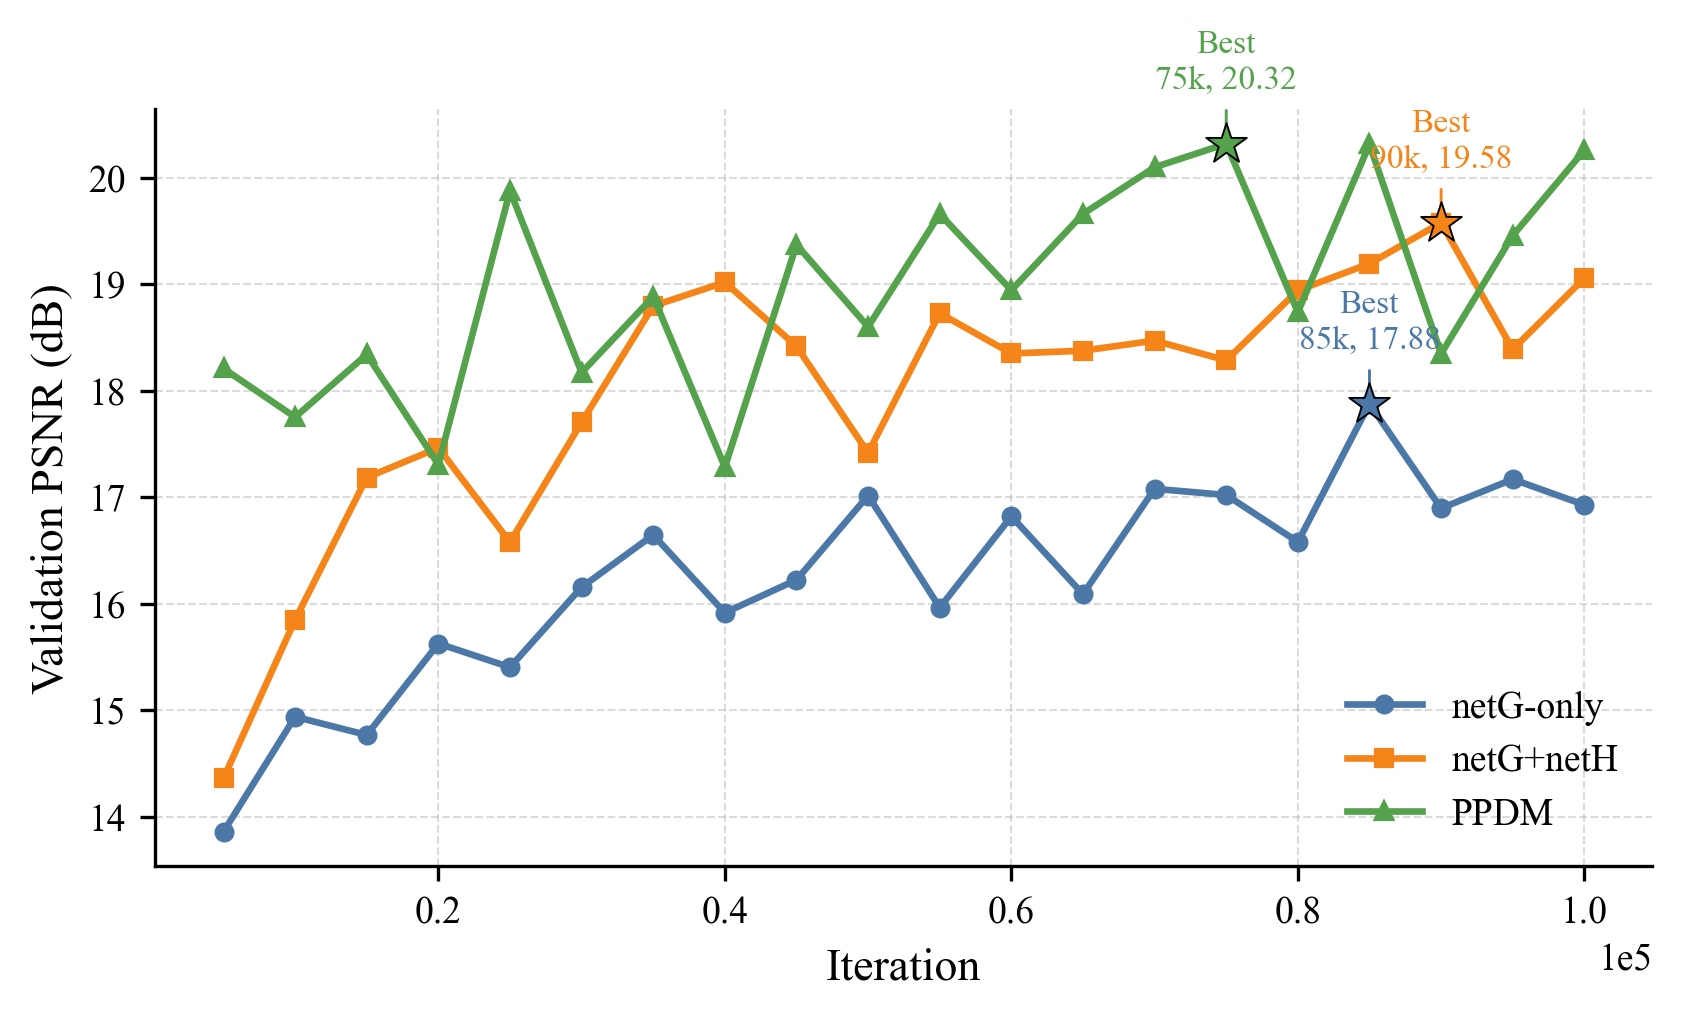

Saved: /mnt/newdisk/Documents/linzhanyang/DehazeDDPM/plot/ch5_ablation/training_curve_comparison.png
Saved: /mnt/newdisk/Documents/linzhanyang/DehazeDDPM/plot/ch5_ablation/training_curve_comparison.pdf


In [3]:
fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.55))

for curve in curves:
    iterations = [p["iteration"] for p in curve["points"]]
    psnr = [p["psnr"] for p in curve["points"]]
    ax.plot(
        iterations,
        psnr,
        label=curve["label"],
        color=curve["color"],
        marker=curve["marker"],
        markersize=3.8,
        linewidth=1.6,
    )

    best = curve["best"]
    ax.scatter(
        best["iteration"],
        best["psnr"],
        marker="*",
        s=105,
        color=curve["color"],
        edgecolor="black",
        linewidth=0.45,
        zorder=5,
    )
    ax.annotate(
        f"Best\n{best['iteration'] // 1000}k, {best['psnr']:.2f}",
        xy=(best["iteration"], best["psnr"]),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color=curve["color"],
        arrowprops={"arrowstyle": "-", "color": curve["color"], "lw": 0.7},
    )

    stop = curve["early_stop"]
    if stop:
        ax.scatter(
            stop["iteration"],
            stop["psnr"],
            marker="X",
            s=58,
            color="white",
            edgecolor=curve["color"],
            linewidth=1.0,
            zorder=6,
        )
        ax.annotate(
            "Early stop",
            xy=(stop["iteration"], stop["psnr"]),
            xytext=(0, -16),
            textcoords="offset points",
            ha="center",
            va="top",
            fontsize=8,
            color=curve["color"],
            arrowprops={"arrowstyle": "-", "color": curve["color"], "lw": 0.7},
        )

ax.set_xlabel("Iteration")
ax.set_ylabel("Validation PSNR (dB)")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.45)
ax.legend(frameon=False, loc="lower right")
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

fig.tight_layout()

png_path = OUTPUT_DIR / "training_curve_comparison.png"
pdf_path = OUTPUT_DIR / "training_curve_comparison.pdf"
# fig.savefig(png_path, bbox_inches="tight")
# fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")
